# Session 14 — Train a Dense Model, Convert it to MoE, and Keep Training

This is a **standalone Session 14 Colab assignment** using `allenai/peS2o`.

1. create a medium-corpus tokenizer and use **FlashTokenizer** for corpus encoding;
2. train a standard **dense (non-MoE) causal language model** from scratch for **5M tokens**;
3. convert every trained feed-forward network into a **4-expert, top-2 MoE**;
4. copy the trained dense FFN into every expert (**sparse upcycling**);
5. verify that conversion preserves the learned function before any MoE optimizer step;
6. continue MoE training for **5M more tokens** on the same peS2o token stream;
7. report loss reduction, total vs active parameters, throughput, peak memory, expert loads, dead experts and expert divergence.

In [1]:
!pip -q install -U "datasets<3.0" "tokenizers>=0.20" "transformers>=4.45" "flash-tokenizer>=0.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.0/374.0 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2024.6.1 which is incompatible.


## 1. Configuration

I use the same ~20M architecture scale as the prior small-model work because it is still practical on a free Colab T4, while the MoE expansion remains small enough for one GPU.

Dense phase: **5M tokens**.  
MoE phase: **5M additional tokens**.

MoE layout:

- 4 routed experts per transformer layer
- top-2 routing
- dropless dispatch
- fp32 router computation
- Switch-style load-balancing auxiliary loss
- router z-loss

In [2]:
import gc, json, math, os, random, time, platform
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from tokenizers import BertWordPieceTokenizer
from transformers import BertTokenizerFast
from flash_tokenizer import BertTokenizerFlash

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Model.
SEQ_LEN = 512
D_MODEL = 384
N_LAYERS = 12
N_HEADS = 6
FF_DIM = 1024
FIXED_BATCH = 8

# Standalone Session 14 training budgets.
DENSE_TOKENS = 5_000_000
MOE_TOKENS = 5_000_000

# Tokenizer/data.
VOCAB_SIZE = 8_192
TOKENIZER_CORPUS_CHARS = 32_000_000   # medium corpus: ~32 MB text
TRAIN_CACHE_TOKENS = 12_000_000
VAL_CACHE_TOKENS = 1_000_000

# MoE.
N_EXPERTS = 4
TOP_K = 2
AUX_ALPHA = 1e-3
Z_ALPHA = 1e-3
ROUTER_INIT_STD = 1e-3

# Fresh dense training + continued MoE training.
MAX_LR = 3e-4
MIN_LR = 3e-5

WORK = Path("/content/s14_moe")
WORK.mkdir(parents=True, exist_ok=True)

if DEVICE.type == "cuda":
    major, minor = torch.cuda.get_device_capability()
    GPU_NAME = torch.cuda.get_device_name(0)
    AMP_DTYPE = torch.bfloat16 if major >= 8 else torch.float16
else:
    GPU_NAME = platform.processor() or platform.machine()
    AMP_DTYPE = torch.float32

print("device:", DEVICE)
print("hardware:", GPU_NAME)
print("AMP dtype:", AMP_DTYPE)
print("dense training:", f"{DENSE_TOKENS:,}", "tokens")
print("MoE continuation:", f"{MOE_TOKENS:,}", "tokens")

device: cuda
hardware: Tesla T4
AMP dtype: torch.float16
dense training: 5,000,000 tokens
MoE continuation: 5,000,000 tokens


## 2. Create a medium-corpus tokenizer and use FlashTokenizer

The assignment asks for FlashTokenizer. FlashTokenizer is an optimized **WordPiece encoding engine**: it consumes a BERT-style vocabulary rather than exposing a raw-corpus vocabulary trainer.

So this notebook uses the technically correct pipeline:

1. stream about **32 MB** of peS2o text;
2. train an **8,192-entry WordPiece vocabulary** with the `tokenizers` WordPiece trainer;
3. save it in BERT format;
4. load that exact vocabulary with `BertTokenizerFlash`;
5. use FlashTokenizer for train/validation corpus encoding;
6. verify FlashTokenizer IDs against `BertTokenizerFast` before training.

In [17]:
import shutil
from transformers import BertTokenizerFast

TOK_DIR = WORK / "pes2o_wordpiece_8192"
CORPUS_TXT = WORK / "tokenizer_corpus.txt"

def build_tokenizer_corpus():
    if CORPUS_TXT.exists() and CORPUS_TXT.stat().st_size >= min(TOKENIZER_CORPUS_CHARS, 1_000_000):
        return
    ds = load_dataset("allenai/peS2o", "v2", split="train", streaming=True, trust_remote_code=True)
    written = docs = 0
    with CORPUS_TXT.open("w", encoding="utf-8") as f:
        for ex in ds:
            txt = (ex.get("text") or "").strip()
            if not txt: continue
            n = TOKENIZER_CORPUS_CHARS - written
            piece = txt[:n]
            f.write(piece + "\n\n")
            written += len(piece) + 2; docs += 1
            if written >= TOKENIZER_CORPUS_CHARS: break
    print(f"tokenizer corpus: {written/1e6:.1f}M chars, {docs:,} docs")

def train_tokenizer():
    if (TOK_DIR / "vocab.txt").exists() and (TOK_DIR / "tokenizer.json").exists():
        try:
            if len(BertTokenizerFast.from_pretrained(str(TOK_DIR))) >= VOCAB_SIZE:
                return
        except Exception:
            pass
        shutil.rmtree(TOK_DIR)

    TOK_DIR.mkdir(parents=True, exist_ok=True)
    wp = BertWordPieceTokenizer(lowercase=False, strip_accents=False)
    wp.train(
        files=[str(CORPUS_TXT)], vocab_size=VOCAB_SIZE, min_frequency=2,
        special_tokens=["[PAD]","[UNK]","[CLS]","[SEP]","[MASK]"]
    )
    wp.save_model(str(TOK_DIR))
    wp.save(str(TOK_DIR / "tokenizer.json"))

build_tokenizer_corpus()
train_tokenizer()

hf_tok = BertTokenizerFast.from_pretrained(str(TOK_DIR))
flash_tok = BertTokenizerFlash(str(TOK_DIR / "vocab.txt"))
PAD_ID, CLS_ID, EOS_ID = hf_tok.pad_token_id, hf_tok.cls_token_id, hf_tok.sep_token_id
ACTUAL_VOCAB = len(hf_tok)

for text in [
    "Reversible networks reconstruct activations.",
    "Scientific papers contain equations and citations."
]:
    a = hf_tok(text, add_special_tokens=True, max_length=512, padding="max_length").input_ids
    b = flash_tok(text, max_length=512).input_ids[0]
    print(text, "\n", a[:20], "\n", b[:20])
    assert a == b
print("✓ FlashTokenizer matches reference tokenizer; vocab =", ACTUAL_VOCAB)

Reversible networks reconstruct activations. 
 [2, 5573, 1572, 3008, 3870, 1307, 3341, 610, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 
 [2, 5573, 1572, 3008, 3870, 1307, 3341, 610, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Scientific papers contain equations and citations. 
 [2, 4097, 6428, 5565, 4827, 986, 71, 2408, 610, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0] 
 [2, 4097, 6428, 5565, 4827, 986, 71, 2408, 610, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0]
✓ FlashTokenizer matches reference tokenizer; vocab = 8192


## 3. Encode peS2o into reusable token caches

The same token stream is used in the dense and MoE phases.

`[SEP]` is used as EOS/document separator. The loss masks the EOS → next-document transition so unrelated papers are not joined as fake next-token examples.

In [18]:
TRAIN_BIN = WORK / "pes2o_train.uint16"
VAL_BIN = WORK / "pes2o_validation.uint16"


def encode_doc(text, max_length=8192):
    ids = flash_tok(text, max_length=max_length).input_ids[0]
    if ids and ids[0] == CLS_ID:
        ids = ids[1:]
    if ids and ids[-1] == EOS_ID:
        ids = ids[:-1]
    return ids


def make_cache(split, target, path):
    if path.exists() and path.stat().st_size // 2 >= target:
        print(path.name, "already available:", f"{path.stat().st_size//2:,}", "tokens")
        return

    ds = load_dataset(
        "allenai/peS2o",
        "v2",
        split=split,
        streaming=True,
        trust_remote_code=True,
    )

    total = docs = 0
    with path.open("wb") as f:
        for ex in ds:
            text = (ex.get("text") or "").strip()
            if not text:
                continue

            ids = encode_doc(text)
            if not ids:
                continue

            arr = np.asarray(ids + [EOS_ID], dtype=np.uint16)
            if total + len(arr) > target:
                arr = arr[:target-total]

            arr.tofile(f)
            total += len(arr)
            docs += 1

            if docs % 1000 == 0:
                print(f"\r{split}: {total/1e6:.2f}M / {target/1e6:.2f}M", end="")

            if total >= target:
                break

    print(f"\n{split}: cached {total:,} tokens from {docs:,} documents")


make_cache("train", TRAIN_CACHE_TOKENS, TRAIN_BIN)
make_cache("validation", VAL_CACHE_TOKENS, VAL_BIN)

train_tokens = np.memmap(TRAIN_BIN, dtype=np.uint16, mode="r")
val_tokens = np.memmap(VAL_BIN, dtype=np.uint16, mode="r")

print("train cache:", f"{len(train_tokens):,}", "tokens")
print("validation cache:", f"{len(val_tokens):,}", "tokens")


def sample_batch(arr, batch=FIXED_BATCH, seq_len=SEQ_LEN):
    hi = len(arr) - seq_len - 1
    starts = np.random.randint(0, hi, size=batch)

    x = np.stack([arr[s:s+seq_len] for s in starts]).astype(np.int64)
    y = np.stack([arr[s+1:s+seq_len+1] for s in starts]).astype(np.int64)

    x = torch.from_numpy(x).to(DEVICE, non_blocking=True)
    y = torch.from_numpy(y).to(DEVICE, non_blocking=True)
    valid = x.ne(EOS_ID)
    return x, y, valid

train: 8.19M / 12.00M
train: cached 12,000,000 tokens from 1,465 documents

validation: cached 1,000,000 tokens from 123 documents
train cache: 12,000,000 tokens
validation cache: 1,000,000 tokens


## 4. Train the standard dense model first

A standard transformer block runs attention and one feed-forward network. This is the dense/linear baseline that will later be upcycled: Session 14's MoE conversion leaves attention unchanged and replaces only the FFN with a router plus experts.

In [19]:
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d))
        self.eps = eps

    def forward(self, x):
        return self.weight * x * torch.rsqrt(
            x.pow(2).mean(-1, keepdim=True) + self.eps
        )

class CausalAttention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        assert d % h == 0
        self.h = h
        self.hd = d // h
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.out = nn.Linear(d, d, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, -1)

        def heads(z):
            return z.view(B, T, self.h, self.hd).transpose(1, 2)

        q, k, v = heads(q), heads(k), heads(v)

        y = F.scaled_dot_product_attention(
            q, k, v,
            is_causal=True,
            dropout_p=0.0,
        )

        return self.out(
            y.transpose(1, 2).contiguous().view(B, T, C)
        )

class DenseTransformerDelta(nn.Module):
    def __init__(self, d, h, ff):
        super().__init__()
        self.n1 = RMSNorm(d)
        self.attn = CausalAttention(d, h)
        self.n2 = RMSNorm(d)
        self.fc1 = nn.Linear(d, ff, bias=False)
        self.fc2 = nn.Linear(ff, d, bias=False)

    def forward(self, x):
        a = self.attn(self.n1(x))
        z = x + a
        m = self.fc2(F.silu(self.fc1(self.n2(z))))
        return a + m

class DenseStack(nn.Module):
    def __init__(self, blocks):
        super().__init__()
        self.blocks = blocks

    def forward(self, x):
        for b in self.blocks:
            x = x + b(x)
        return x

class DenseTinyLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok = nn.Embedding(ACTUAL_VOCAB, D_MODEL)
        self.pos = nn.Embedding(SEQ_LEN, D_MODEL)

        self.stack = DenseStack(
            nn.ModuleList([
                DenseTransformerDelta(D_MODEL, N_HEADS, FF_DIM)
                for _ in range(N_LAYERS)
            ])
        )

        self.norm = RMSNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, ACTUAL_VOCAB, bias=False)
        self.head.weight = self.tok.weight

    def forward(self, tokens):
        pos = torch.arange(tokens.size(1), device=tokens.device)
        x = self.tok(tokens) + self.pos(pos)[None]
        return self.norm(self.stack(x))

    def logits(self, hidden):
        return self.head(hidden)

def ac():
    if DEVICE.type == "cuda":
        return torch.autocast("cuda", dtype=AMP_DTYPE)
    return nullcontext()


dense = DenseTinyLM().to(DEVICE)

DENSE_PARAMS = sum(p.numel() for p in dense.parameters())

print("fresh dense model")
print("dense parameters:", f"{DENSE_PARAMS:,} ({DENSE_PARAMS/1e6:.3f}M)")
assert 19_000_000 <= DENSE_PARAMS <= 21_000_000


fresh dense model
dense parameters: 19,867,008 (19.867M)


## 5. Establish the untrained dense loss

For an 8,192-token vocabulary, an approximately uniform untrained predictor has cross-entropy near `log(8192) ≈ 9.01`. The important assignment evidence is that the dense model's training and fixed validation losses both fall before conversion.

In [20]:
def dense_lm_loss(model, x, y, valid):
    logits = model.logits(model(x))
    B, T, V = logits.shape

    per_token = F.cross_entropy(
        logits.reshape(-1, V),
        y.reshape(-1),
        reduction="none",
    ).view(B, T)

    w = valid.to(per_token.dtype)
    return (per_token * w).sum() / w.sum().clamp_min(1)


EVAL_BATCHES = 20
rng = np.random.default_rng(12345)
_eval_starts = rng.integers(
    0,
    len(val_tokens) - SEQ_LEN - 1,
    size=(EVAL_BATCHES, FIXED_BATCH),
)


def fixed_eval_batch(starts):
    x = np.stack([val_tokens[s:s+SEQ_LEN] for s in starts]).astype(np.int64)
    y = np.stack([val_tokens[s+1:s+SEQ_LEN+1] for s in starts]).astype(np.int64)
    x = torch.from_numpy(x).to(DEVICE)
    y = torch.from_numpy(y).to(DEVICE)
    return x, y, x.ne(EOS_ID)


@torch.no_grad()
def evaluate_dense(model):
    model.eval()
    vals = []

    for starts in _eval_starts:
        x, y, valid = fixed_eval_batch(starts)
        with ac():
            vals.append(float(dense_lm_loss(model, x, y, valid)))

    model.train()
    return float(np.mean(vals))


DENSE_INITIAL_VAL = evaluate_dense(dense)
print("untrained dense fixed validation loss:", f"{DENSE_INITIAL_VAL:.6f}")
print("log(vocab):", f"{math.log(ACTUAL_VOCAB):.6f}")

untrained dense fixed validation loss: 9.229876
log(vocab): 9.010913


## 6. Train the dense model for 5M tokens

This phase satisfies the first half of the assignment: the standard model must visibly learn before it is converted.

In [21]:
def clear_cuda():
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def training_lr(step, steps, hi=MAX_LR, lo=MIN_LR):
    warm = max(20, int(0.05 * steps))
    if step < warm:
        return hi * (step + 1) / warm
    r = min(1.0, (step - warm) / max(1, steps - warm))
    return lo + 0.5 * (hi - lo) * (1 + math.cos(math.pi * r))


def train_dense(model, target_tokens=DENSE_TOKENS):
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=MAX_LR,
        betas=(0.9, 0.95),
        weight_decay=0.1,
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(DEVICE.type == "cuda" and AMP_DTYPE == torch.float16),
    )

    tokens_per_step = FIXED_BATCH * SEQ_LEN
    steps = math.ceil(target_tokens / tokens_per_step)
    losses = []
    seen = 0

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    t0 = time.perf_counter()

    for step in range(steps):
        lr = training_lr(step, steps)
        for pg in opt.param_groups:
            pg["lr"] = lr

        x, y, valid = sample_batch(train_tokens, FIXED_BATCH)
        opt.zero_grad(set_to_none=True)

        with ac():
            loss = dense_lm_loss(model, x, y, valid)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()

        losses.append(float(loss))
        seen += tokens_per_step

        if step % 50 == 0 or step == steps - 1:
            print(
                f"dense step {step+1:4d}/{steps} "
                f"tokens={seen/1e6:.2f}M loss={loss.item():.5f} "
                f"grad={float(grad_norm):.3f}"
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    wall = time.perf_counter() - t0
    peak = torch.cuda.max_memory_allocated() / 2**30 if DEVICE.type == "cuda" else float("nan")

    return {
        "loss_curve": losses,
        "tokens_seen": seen,
        "token_s": seen / wall,
        "peak_GiB": peak,
        "wall_s": wall,
    }


clear_cuda()
dense_train = train_dense(dense)
DENSE_FINAL_VAL = evaluate_dense(dense)

print("\nDense validation:")
print("before training:", f"{DENSE_INITIAL_VAL:.6f}")
print("after +5M:     ", f"{DENSE_FINAL_VAL:.6f}")
print("dense token/s:", f"{dense_train['token_s']:,.0f}")
print("dense peak GiB:", f"{dense_train['peak_GiB']:.2f}")

torch.save(
    {"model": dense.state_dict(), "val_loss": DENSE_FINAL_VAL},
    WORK / "dense_5m_tokens.pt",
)

/tmp/ipykernel_1077/2727565430.py:57: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(loss))


dense step    1/1221 tokens=0.00M loss=0.00000 grad=0.000
dense step   51/1221 tokens=0.21M loss=0.00000 grad=0.000
dense step  101/1221 tokens=0.41M loss=2.65264 grad=0.987
dense step  151/1221 tokens=0.62M loss=1.32272 grad=0.997
dense step  201/1221 tokens=0.82M loss=1.71559 grad=0.497
dense step  251/1221 tokens=1.03M loss=1.19653 grad=0.427
dense step  301/1221 tokens=1.23M loss=0.00002 grad=0.001
dense step  351/1221 tokens=1.44M loss=1.65542 grad=0.676
dense step  401/1221 tokens=1.64M loss=0.83486 grad=0.443
dense step  451/1221 tokens=1.85M loss=2.56383 grad=0.841
dense step  501/1221 tokens=2.05M loss=0.80484 grad=0.913
dense step  551/1221 tokens=2.26M loss=1.11492 grad=0.551
dense step  601/1221 tokens=2.46M loss=1.11618 grad=0.435
dense step  651/1221 tokens=2.67M loss=1.48060 grad=0.457
dense step  701/1221 tokens=2.87M loss=0.18504 grad=0.102
dense step  751/1221 tokens=3.08M loss=0.00028 grad=0.017
dense step  801/1221 tokens=3.28M loss=0.55582 grad=0.218
dense step  85

## 7. Convert the trained dense FFNs into a four-expert MoE

### Router

For each token \(x\), the router computes:

\[
r = xW_r
\]

followed by softmax. The top-2 experts are selected and their retained probabilities are renormalized to sum to 1.

### Experts

Every expert has the same two linear matrices as the original dense FFN:

\[
\text{Expert}_i(x)=W_{2,i}\,\text{SiLU}(W_{1,i}x)
\]

At conversion time all four experts receive an **exact copy** of the trained dense `fc1` and `fc2`.

### Dropless routing

There is no capacity limit in this single-GPU teaching implementation. Every selected token is processed.

### Load-balancing loss

For each layer:

\[
L_{\text{balance}}
=
N\sum_{i=1}^{N} f_iP_i
\]

where \(f_i\) is the fraction of selected assignments going to expert \(i\), and \(P_i\) is its average router probability. The training objective is:

\[
L=L_{\text{LM}}+\alpha L_{\text{balance}}+\beta L_z
\]

with \(\alpha=\beta=0.001\).

In [22]:
class ExpertFFN(nn.Module):
    def __init__(self, d, ff):
        super().__init__()
        self.fc1 = nn.Linear(d, ff, bias=False)
        self.fc2 = nn.Linear(ff, d, bias=False)

    def forward(self, x):
        return self.fc2(F.silu(self.fc1(x)))

class SparseMoE(nn.Module):
    def __init__(self, d, ff, n_experts=N_EXPERTS, top_k=TOP_K):
        super().__init__()
        assert 1 <= top_k <= n_experts

        self.n_experts = n_experts
        self.top_k = top_k

        self.router = nn.Linear(d, n_experts, bias=False)
        self.experts = nn.ModuleList([
            ExpertFFN(d, ff)
            for _ in range(n_experts)
        ])

        # Small router initialization: expert choice begins near symmetric.
        nn.init.normal_(self.router.weight, mean=0.0, std=ROUTER_INIT_STD)

    def forward(self, x):
        original_shape = x.shape
        flat = x.reshape(-1, x.size(-1))
        n_tokens = flat.size(0)

        # Router in fp32 for stability.
        logits = self.router(flat.float())
        probs = torch.softmax(logits, dim=-1)

        top_prob, top_idx = torch.topk(
            probs,
            k=self.top_k,
            dim=-1,
        )

        # Retained expert weights add to one.
        top_weight = top_prob / top_prob.sum(
            dim=-1,
            keepdim=True,
        ).clamp_min(1e-9)

        out = torch.zeros_like(flat)

        # Dropless dispatch. Only selected token/expert pairs are evaluated.
        for expert_id, expert in enumerate(self.experts):
            token_idx, slot_idx = torch.where(top_idx == expert_id)

            if token_idx.numel() == 0:
                continue

            expert_in = flat.index_select(0, token_idx)
            expert_out = expert(expert_in)

            weights = top_weight[token_idx, slot_idx].to(expert_out.dtype)
            expert_out = expert_out * weights.unsqueeze(-1)

            out.index_add_(0, token_idx, expert_out)

        # f_i: fraction of selected expert assignments.
        assignment = F.one_hot(
            top_idx,
            num_classes=self.n_experts,
        ).float()

        load = assignment.mean(dim=(0, 1))
        prob_mean = probs.mean(dim=0)

        balance_raw = self.n_experts * torch.sum(
            load.detach() * prob_mean
        )

        # ST-MoE-style router z-loss.
        z_raw = torch.logsumexp(logits, dim=-1).square().mean()

        return (
            out.reshape(original_shape),
            balance_raw,
            z_raw,
            load.detach(),
            prob_mean.detach(),
        )

class MoETransformerDelta(nn.Module):
    def __init__(self, d, h, ff):
        super().__init__()
        self.n1 = RMSNorm(d)
        self.attn = CausalAttention(d, h)
        self.n2 = RMSNorm(d)
        self.moe = SparseMoE(d, ff)

    def forward(self, x):
        a = self.attn(self.n1(x))
        z = x + a

        m, balance, zloss, load, prob = self.moe(self.n2(z))
        return a + m, balance, zloss, load, prob

class MoEStack(nn.Module):
    def __init__(self, blocks):
        super().__init__()
        self.blocks = blocks

    def forward(self, x):
        balances = []
        zlosses = []
        loads = []
        probs = []

        for block in self.blocks:
            delta, bal, zl, load, prob = block(x)
            x = x + delta

            balances.append(bal)
            zlosses.append(zl)
            loads.append(load)
            probs.append(prob)

        return (
            x,
            torch.stack(balances).mean(),
            torch.stack(zlosses).mean(),
            torch.stack(loads),
            torch.stack(probs),
        )

class MoETinyLM(nn.Module):
    def __init__(self):
        super().__init__()

        self.tok = nn.Embedding(ACTUAL_VOCAB, D_MODEL)
        self.pos = nn.Embedding(SEQ_LEN, D_MODEL)

        self.stack = MoEStack(
            nn.ModuleList([
                MoETransformerDelta(D_MODEL, N_HEADS, FF_DIM)
                for _ in range(N_LAYERS)
            ])
        )

        self.norm = RMSNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, ACTUAL_VOCAB, bias=False)
        self.head.weight = self.tok.weight

    def forward(self, tokens):
        pos = torch.arange(tokens.size(1), device=tokens.device)
        x = self.tok(tokens) + self.pos(pos)[None]

        x, balance, zloss, loads, probs = self.stack(x)
        hidden = self.norm(x)

        return hidden, balance, zloss, loads, probs

    def logits(self, hidden):
        return self.head(hidden)

## 8. Sparse upcycling: copy the trained dense FFN into every expert

Session 14 describes **upcycling** as growing a standard model into an MoE without throwing away what it already learned. Attention, norms, embeddings and the output head are copied once. Every new expert receives an exact copy of the trained dense `fc1/fc2`; only the router is new.

In [23]:
def upcycle_dense_to_moe(dense_model):
    moe = MoETinyLM().to(DEVICE)

    # Shared model components.
    moe.tok.load_state_dict(dense_model.tok.state_dict())
    moe.pos.load_state_dict(dense_model.pos.state_dict())
    moe.norm.load_state_dict(dense_model.norm.state_dict())

    # head.weight is tied to tok.weight in both models.

    for dense_block, moe_block in zip(
        dense_model.stack.blocks,
        moe.stack.blocks,
    ):
        moe_block.n1.load_state_dict(dense_block.n1.state_dict())
        moe_block.attn.load_state_dict(dense_block.attn.state_dict())
        moe_block.n2.load_state_dict(dense_block.n2.state_dict())

        for expert in moe_block.moe.experts:
            expert.fc1.load_state_dict(dense_block.fc1.state_dict())
            expert.fc2.load_state_dict(dense_block.fc2.state_dict())

    return moe

moe = upcycle_dense_to_moe(dense)

MOE_TOTAL_PARAMS = sum(p.numel() for p in moe.parameters())

expert_bank_params = 0
active_expert_params = 0

for block in moe.stack.blocks:
    per_expert = sum(
        p.numel()
        for p in block.moe.experts[0].parameters()
    )

    expert_bank_params += per_expert * N_EXPERTS
    active_expert_params += per_expert * TOP_K

shared_and_router = MOE_TOTAL_PARAMS - expert_bank_params
MOE_ACTIVE_PARAMS = shared_and_router + active_expert_params

print("dense parameters:", f"{DENSE_PARAMS:,}")
print("MoE total parameters:", f"{MOE_TOTAL_PARAMS:,}")
print("MoE active parameters/token (approx):", f"{MOE_ACTIVE_PARAMS:,}")
print("total / dense:", f"{MOE_TOTAL_PARAMS/DENSE_PARAMS:.2f}x")
print("active / dense:", f"{MOE_ACTIVE_PARAMS/DENSE_PARAMS:.2f}x")
print("experts/layer:", N_EXPERTS, "top-k:", TOP_K)

dense parameters: 19,867,008
MoE total parameters: 48,196,992
MoE active parameters/token (approx): 29,322,624
total / dense: 2.43x
active / dense: 1.48x
experts/layer: 4 top-k: 2


## 9. Prove the conversion preserved the learned function

This is an important upcycling check.

Before training the new MoE at all, the same mini-batch is passed through:

- the post-continuation dense model;
- the freshly upcycled MoE.

Since every selected expert is initially the same dense FFN and its top-2 weights sum to one, the LM logits and LM loss should be nearly identical.

In [26]:
@torch.no_grad()
def conversion_audit(dense_model, moe_model):
    dense_model.eval()
    moe_model.eval()

    x, y, valid = fixed_eval_batch(_eval_starts[0])

    # Run verification in float32 to prevent half-precision type mismatches
    # during inplace operations like index_add_ inside custom MoE layers.
    with torch.autocast("cuda", enabled=False):
        dense_logits = dense_model.logits(dense_model(x))

        hidden, bal, zl, loads, probs = moe_model(x)
        moe_logits = moe_model.logits(hidden)

        B, T, V = dense_logits.shape

        dense_token_loss = F.cross_entropy(
            dense_logits.reshape(-1, V),
            y.reshape(-1),
            reduction="none",
        ).view(B, T)

        moe_token_loss = F.cross_entropy(
            moe_logits.reshape(-1, V),
            y.reshape(-1),
            reduction="none",
        ).view(B, T)

        w = valid.to(dense_token_loss.dtype)

        dense_loss = (
            (dense_token_loss * w).sum()
            / w.sum().clamp_min(1)
        )

        moe_loss = (
            (moe_token_loss * w).sum()
            / w.sum().clamp_min(1)
        )

    dense_model.train()
    moe_model.train()

    max_logit_diff = (
        dense_logits.float() - moe_logits.float()
    ).abs().max().item()

    loss_diff = abs(
        float(dense_loss) - float(moe_loss)
    )

    return {
        "dense_loss": float(dense_loss),
        "moe_loss": float(moe_loss),
        "loss_diff": loss_diff,
        "max_logit_diff": max_logit_diff,
        "mean_layer_load": loads.float().mean(0).cpu().tolist(),
    }

CONVERSION_AUDIT = conversion_audit(dense, moe)

print(json.dumps(CONVERSION_AUDIT, indent=2))

# Allow tiny mixed-precision accumulation differences.
assert CONVERSION_AUDIT["loss_diff"] < 1e-3, (
    "Upcycling changed LM loss too much before training."
)

{
  "dense_loss": 0.00019579162471927702,
  "moe_loss": 0.00019579185754992068,
  "loss_diff": 2.3283064365386963e-10,
  "max_logit_diff": 4.1961669921875e-05,
  "mean_layer_load": [
    0.3179524838924408,
    0.1089681014418602,
    0.2823079526424408,
    0.290771484375
  ]
}


## 10. MoE language-model objective and router diagnostics

The logged values distinguish:

- **LM loss** — the actual next-token objective;
- **balance loss** — router regularizer;
- **z-loss** — router-logit stability term;
- **MaxVio** — how much busier the busiest expert is than the mean;
- **dead experts** — experts receiving no assignments in the measured batch.

For four experts with top-2 routing, perfectly even assignment load is 25% per expert because the load fractions are normalized over all selected assignments.

In [28]:
def moe_lm_loss(model, x, y, valid):
    hidden, balance_raw, z_raw, loads, probs = model(x)
    logits = model.logits(hidden)

    B, T, V = logits.shape

    per_token = F.cross_entropy(
        logits.reshape(-1, V),
        y.reshape(-1),
        reduction="none",
    ).view(B, T)

    w = valid.to(per_token.dtype)
    lm = (per_token * w).sum() / w.sum().clamp_min(1)

    total = (
        lm
        + AUX_ALPHA * balance_raw
        + Z_ALPHA * z_raw
    )

    return total, lm, balance_raw, z_raw, loads, probs

def router_summary(loads):
    # loads: [layers, experts], each layer sums to 1.
    mean_load = loads.float().mean(dim=0)
    ideal = 1.0 / N_EXPERTS

    maxvio_by_layer = (
        (loads.float().max(dim=1).values - ideal)
        / ideal
    )

    dead = (loads == 0).sum().item()

    return {
        "mean_load": mean_load.detach().cpu().tolist(),
        "mean_maxvio": float(maxvio_by_layer.mean()),
        "max_maxvio": float(maxvio_by_layer.max()),
        "dead_expert_slots": int(dead),
    }

@torch.no_grad()
def evaluate_moe(model):
    model.eval()

    lm_vals = []
    balances = []
    zvals = []
    load_accum = []

    for starts in _eval_starts:
        x, y, valid = fixed_eval_batch(starts)

        # Disable mixed-precision during evaluation to prevent index_add_ type mismatches
        with torch.autocast("cuda", enabled=False):
            total, lm, bal, zl, loads, probs = moe_lm_loss(
                model, x, y, valid
            )

        lm_vals.append(float(lm))
        balances.append(float(bal))
        zvals.append(float(zl))
        load_accum.append(loads.float().cpu())

    model.train()

    mean_loads = torch.stack(load_accum).mean(dim=0)
    route = router_summary(mean_loads)

    return {
        "lm_loss": float(np.mean(lm_vals)),
        "balance_raw": float(np.mean(balances)),
        "z_raw": float(np.mean(zvals)),
        **route,
    }

MOE_START_EVAL = evaluate_moe(moe)
print(json.dumps(MOE_START_EVAL, indent=2))

{
  "lm_loss": 0.4283455515818787,
  "balance_raw": 1.0126826107501983,
  "z_raw": 1.9187454402446746,
  "mean_load": [
    0.31878459453582764,
    0.11038360744714737,
    0.28226929903030396,
    0.28856250643730164
  ],
  "mean_maxvio": 0.9764872193336487,
  "max_maxvio": 1.0,
  "dead_expert_slots": 14
}


## 11. Continue training the upcycled MoE for 5M more tokens

Both the copied experts and the new routers are trainable.

At the end I compare:

- first 100 vs last 100 MoE LM-loss steps;
- fixed validation loss before vs after MoE training;
- expert loads and MaxVio;
- whether the experts actually diverged from their initially identical copies.

In [30]:
def expert_divergence(model):
    distances = []

    with torch.no_grad():
        for block in model.stack.blocks:
            ref = block.moe.experts[0]

            for expert in block.moe.experts[1:]:
                d1 = (
                    expert.fc1.weight.float()
                    - ref.fc1.weight.float()
                ).pow(2).mean().sqrt()

                d2 = (
                    expert.fc2.weight.float()
                    - ref.fc2.weight.float()
                ).pow(2).mean().sqrt()

                distances.append(float((d1 + d2) / 2))

    return float(np.mean(distances))

def train_moe(model, target_tokens=MOE_TOKENS):
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=MAX_LR,
        betas=(0.9, 0.95),
        weight_decay=0.1,
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(DEVICE.type == "cuda" and AMP_DTYPE == torch.float16),
    )

    tokens_per_step = FIXED_BATCH * SEQ_LEN
    steps = math.ceil(target_tokens / tokens_per_step)

    lm_losses = []
    total_losses = []
    balance_losses = []
    z_losses = []
    maxvios = []
    dead_counts = []

    seen = 0

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    t0 = time.perf_counter()

    for step in range(steps):
        lr = training_lr(step, steps)

        for pg in opt.param_groups:
            pg["lr"] = lr

        x, y, valid = sample_batch(train_tokens, FIXED_BATCH)
        opt.zero_grad(set_to_none=True)

        # Patching SparseMoE on the fly to prevent the index_add_ type mismatch
        for block in model.stack.blocks:
            orig_forward = block.moe.forward
            def patched_forward(x, moe_layer=block.moe):
                original_shape = x.shape
                flat = x.reshape(-1, x.size(-1))
                n_tokens = flat.size(0)
                logits = moe_layer.router(flat.float())
                probs = torch.softmax(logits, dim=-1)
                top_prob, top_idx = torch.topk(probs, k=moe_layer.top_k, dim=-1)
                top_weight = top_prob / top_prob.sum(dim=-1, keepdim=True).clamp_min(1e-9)
                out = torch.zeros_like(flat)

                for expert_id, expert in enumerate(moe_layer.experts):
                    token_idx, slot_idx = torch.where(top_idx == expert_id)
                    if token_idx.numel() == 0:
                        continue
                    expert_in = flat.index_select(0, token_idx)
                    expert_out = expert(expert_in)
                    weights = top_weight[token_idx, slot_idx].to(expert_out.dtype)
                    expert_out = expert_out * weights.unsqueeze(-1)
                    # Explicitly cast to target tensor's precision to handle AMP correctly
                    out.index_add_(0, token_idx, expert_out.to(out.dtype))

                assignment = F.one_hot(top_idx, num_classes=moe_layer.n_experts).float()
                load = assignment.mean(dim=(0, 1))
                prob_mean = probs.mean(dim=0)
                balance_raw = moe_layer.n_experts * torch.sum(load.detach() * prob_mean)
                z_raw = torch.logsumexp(logits, dim=-1).square().mean()
                return out.reshape(original_shape), balance_raw, z_raw, load.detach(), prob_mean.detach()

            block.moe.forward = patched_forward

        with ac():
            total, lm, bal, zl, loads, probs = moe_lm_loss(
                model, x, y, valid
            )

        scaler.scale(total).backward()
        scaler.unscale_(opt)

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0,
        )

        scaler.step(opt)
        scaler.update()

        route = router_summary(loads)

        total_losses.append(float(total))
        lm_losses.append(float(lm))
        balance_losses.append(float(bal))
        z_losses.append(float(zl))
        maxvios.append(route["mean_maxvio"])
        dead_counts.append(route["dead_expert_slots"])

        seen += tokens_per_step

        if step % 50 == 0 or step == steps - 1:
            print(
                f"MoE step {step+1:4d}/{steps} "
                f"tokens={seen/1e6:6.2f}M "
                f"LM={lm.item():.5f} "
                f"bal={bal.item():.3f} "
                f"MaxVio={route["mean_maxvio"]:.3f} "
                f"dead={route["dead_expert_slots"]:2d} "
                f"grad={float(grad_norm):.3f}"
            )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    wall = time.perf_counter() - t0

    peak = (
        torch.cuda.max_memory_allocated() / 2**30
        if DEVICE.type == "cuda"
        else float("nan")
    )

    return {
        "tokens_seen": seen,
        "lm_loss_curve": lm_losses,
        "total_loss_curve": total_losses,
        "balance_curve": balance_losses,
        "z_curve": z_losses,
        "maxvio_curve": maxvios,
        "dead_curve": dead_counts,
        "token_s": seen / wall,
        "peak_GiB": peak,
        "wall_s": wall,
    }

MOE_DIVERGENCE_BEFORE = expert_divergence(moe)
moe_train = train_moe(moe)
MOE_DIVERGENCE_AFTER = expert_divergence(moe)

MOE_FINAL_EVAL = evaluate_moe(moe)

print("\nMoE fixed validation LM loss:")
print("before MoE training:", f"{MOE_START_EVAL["lm_loss"]:.6f}")
print("after MoE training: ", f"{MOE_FINAL_EVAL["lm_loss"]:.6f}")

print("\nExpert divergence:")
print("before:", f"{MOE_DIVERGENCE_BEFORE:.8f}")
print("after: ", f"{MOE_DIVERGENCE_AFTER:.8f}")

print("\nMean final expert assignment load:")
for i, load in enumerate(MOE_FINAL_EVAL["mean_load"]):
    print(f"expert {i}: {100*load:.2f}%")

print("final mean MaxVio:", f"{MOE_FINAL_EVAL["mean_maxvio"]:.3f}")
print("final dead expert slots:", MOE_FINAL_EVAL["dead_expert_slots"])
print("MoE token/s:", f"{moe_train["token_s"]:,.0f}")
print("MoE peak GiB:", f"{moe_train["peak_GiB"]:.2f}")

torch.save(
    {
        "model": moe.state_dict(),
        "config": {
            "n_experts": N_EXPERTS,
            "top_k": TOP_K,
            "aux_alpha": AUX_ALPHA,
            "z_alpha": Z_ALPHA,
            "dense_params": DENSE_PARAMS,
            "moe_total_params": MOE_TOTAL_PARAMS,
            "moe_active_params": MOE_ACTIVE_PARAMS,
        },
    },
    WORK / "moe_final.pt",
)

MoE step    1/1221 tokens=  0.00M LM=0.08228 bal=1.013 MaxVio=0.990 dead=15 grad=0.055
MoE step   51/1221 tokens=  0.21M LM=0.00006 bal=1.173 MaxVio=0.974 dead=20 grad=0.005
MoE step  101/1221 tokens=  0.41M LM=0.00011 bal=1.200 MaxVio=0.999 dead=22 grad=0.007
MoE step  151/1221 tokens=  0.62M LM=0.00008 bal=1.253 MaxVio=0.981 dead=21 grad=0.006
MoE step  201/1221 tokens=  0.82M LM=1.32226 bal=1.172 MaxVio=0.936 dead=17 grad=1.115
MoE step  251/1221 tokens=  1.03M LM=0.00001 bal=1.158 MaxVio=0.967 dead=20 grad=0.004
MoE step  301/1221 tokens=  1.23M LM=0.20984 bal=1.155 MaxVio=0.948 dead=17 grad=0.126
MoE step  351/1221 tokens=  1.44M LM=1.34670 bal=1.102 MaxVio=0.891 dead=11 grad=1.063
MoE step  401/1221 tokens=  1.64M LM=0.17388 bal=1.089 MaxVio=0.938 dead=15 grad=0.084
MoE step  451/1221 tokens=  1.85M LM=0.00004 bal=1.139 MaxVio=0.936 dead=18 grad=0.004
MoE step  501/1221 tokens=  2.05M LM=1.18989 bal=1.138 MaxVio=0.928 dead=17 grad=0.619
MoE step  551/1221 tokens=  2.26M LM=0.7253

## 12. Demonstrate that both phases learned

The assignment's key requirement is that training continues and loss reduces. I therefore compare first-100 vs last-100 training loss and fixed validation loss for both phases, while also reporting the near-zero loss discontinuity at dense → MoE conversion.

In [31]:
def mean_edge(values, n=100):
    n = min(n, len(values))
    return float(np.mean(values[:n])), float(np.mean(values[-n:]))


DENSE_FIRST100, DENSE_LAST100 = mean_edge(dense_train["loss_curve"], 100)
MOE_FIRST100, MOE_LAST100 = mean_edge(moe_train["lm_loss_curve"], 100)

print("DENSE")
print("fixed val before:       ", f"{DENSE_INITIAL_VAL:.6f}")
print("fixed val after +5M:    ", f"{DENSE_FINAL_VAL:.6f}")
print("first-100 train mean:   ", f"{DENSE_FIRST100:.6f}")
print("last-100 train mean:    ", f"{DENSE_LAST100:.6f}")

print("\nCONVERSION")
print("dense conversion loss:  ", f"{CONVERSION_AUDIT['dense_loss']:.6f}")
print("MoE conversion loss:    ", f"{CONVERSION_AUDIT['moe_loss']:.6f}")
print("conversion loss diff:   ", f"{CONVERSION_AUDIT['loss_diff']:.8f}")

print("\nMOE")
print("fixed val at MoE start: ", f"{MOE_START_EVAL['lm_loss']:.6f}")
print("fixed val after +5M:    ", f"{MOE_FINAL_EVAL['lm_loss']:.6f}")
print("first-100 train mean:   ", f"{MOE_FIRST100:.6f}")
print("last-100 train mean:    ", f"{MOE_LAST100:.6f}")

assert DENSE_LAST100 < DENSE_FIRST100, "Dense training loss did not decrease."
assert MOE_LAST100 < MOE_FIRST100, "MoE training loss did not decrease; inspect routing or train longer."

print("\n✓ Dense training loss decreased.")
print("✓ MoE training loss decreased.")

if MOE_FINAL_EVAL["lm_loss"] < MOE_START_EVAL["lm_loss"]:
    print("✓ MoE fixed validation loss decreased.")
else:
    print("⚠ MoE fixed validation loss did not decrease; report honestly or train longer.")

DENSE
fixed val before:        9.229876
fixed val after +5M:     0.428352
first-100 train mean:    3.058409
last-100 train mean:     0.441072

CONVERSION
dense conversion loss:   0.000196
MoE conversion loss:     0.000196
conversion loss diff:    0.00000000

MOE
fixed val at MoE start:  0.428346
fixed val after +5M:     0.308779
first-100 train mean:    0.513094
last-100 train mean:     0.301471

✓ Dense training loss decreased.
✓ MoE training loss decreased.
✓ MoE fixed validation loss decreased.


## 13. Plots

The first plot shows the two continuation phases. The vertical boundary marks dense → MoE conversion.

The router plot shows whether all experts remain in use instead of collapsing.

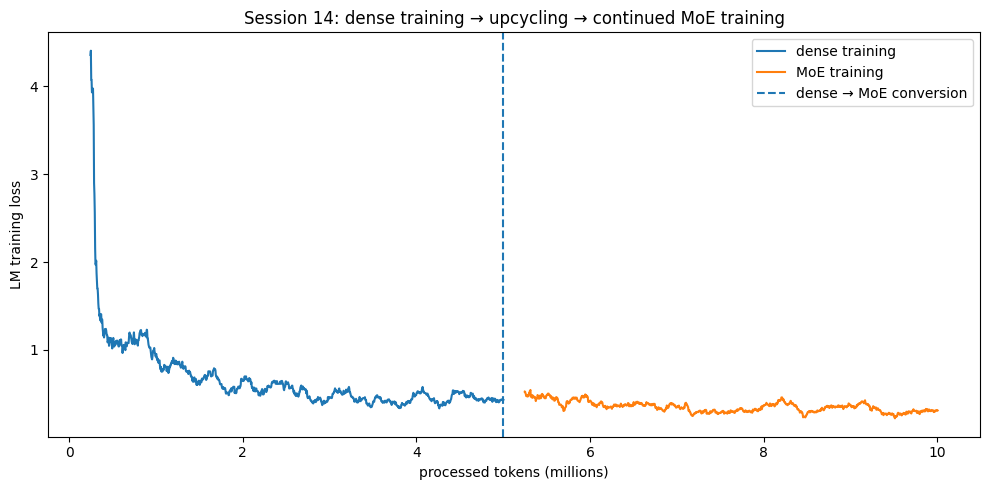

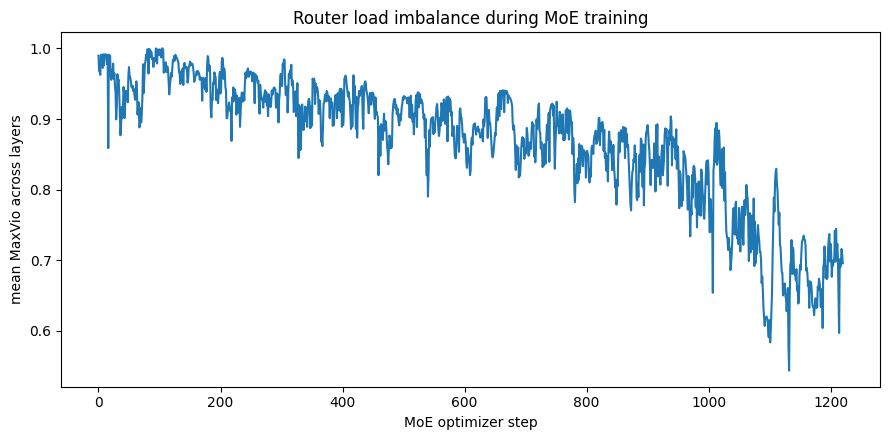

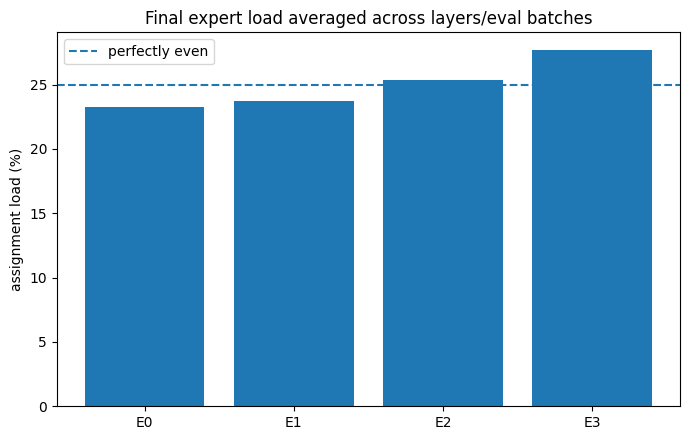

In [32]:
# Combined training-loss plot.
plt.figure(figsize=(10, 5))

dense_x = np.linspace(
    0,
    dense_train["tokens_seen"] / 1e6,
    len(dense_train["loss_curve"]),
)

moe_x = (
    dense_train["tokens_seen"] / 1e6
    + np.linspace(
        0,
        moe_train["tokens_seen"] / 1e6,
        len(moe_train["lm_loss_curve"]),
    )
)

def smooth(a, max_window=100):
    a = np.asarray(a)
    k = min(max_window, max(1, len(a)//20))
    if k <= 1:
        return a, 0
    return np.convolve(a, np.ones(k)/k, mode="valid"), k-1

yd, od = smooth(dense_train["loss_curve"])
ym, om = smooth(moe_train["lm_loss_curve"])

plt.plot(dense_x[od:], yd, label="dense training")
plt.plot(moe_x[om:], ym, label="MoE training")

boundary = dense_train["tokens_seen"] / 1e6
plt.axvline(
    boundary,
    linestyle="--",
    label="dense → MoE conversion",
)

plt.xlabel("processed tokens (millions)")
plt.ylabel("LM training loss")
plt.title("Session 14: dense training → upcycling → continued MoE training")
plt.legend()
plt.tight_layout()
plt.savefig(WORK / "dense_to_moe_loss.png", dpi=160)
plt.show()

# Router balance through MoE training.
plt.figure(figsize=(9, 4.5))
plt.plot(moe_train["maxvio_curve"])
plt.xlabel("MoE optimizer step")
plt.ylabel("mean MaxVio across layers")
plt.title("Router load imbalance during MoE training")
plt.tight_layout()
plt.savefig(WORK / "router_maxvio.png", dpi=160)
plt.show()

# Final mean expert assignment load.
plt.figure(figsize=(7, 4.5))
plt.bar(
    [f"E{i}" for i in range(N_EXPERTS)],
    [100*x for x in MOE_FINAL_EVAL["mean_load"]],
)
plt.axhline(
    100 / N_EXPERTS,
    linestyle="--",
    label="perfectly even",
)
plt.ylabel("assignment load (%)")
plt.title("Final expert load averaged across layers/eval batches")
plt.legend()
plt.tight_layout()
plt.savefig(WORK / "final_expert_load.png", dpi=160)
plt.show()

## 14. Generate the measured README section

This cell produces `README_RESULTS.md` and `session14_results.json` from the real Colab measurements. Paste that generated section into the final GitHub README rather than inventing numbers.

In [33]:
RESULTS = {
    "hardware": GPU_NAME,
    "precision": str(AMP_DTYPE),
    "dataset": "allenai/peS2o v2",
    "tokenizer": "8192 WordPiece vocabulary + FlashTokenizer encoding",
    "dense_parameters": DENSE_PARAMS,
    "moe_total_parameters": MOE_TOTAL_PARAMS,
    "moe_active_parameters_approx": MOE_ACTIVE_PARAMS,
    "n_experts": N_EXPERTS,
    "top_k": TOP_K,
    "aux_alpha": AUX_ALPHA,
    "z_alpha": Z_ALPHA,
    "dense_initial_val_loss": DENSE_INITIAL_VAL,
    "dense_final_val_loss": DENSE_FINAL_VAL,
    "conversion_audit": CONVERSION_AUDIT,
    "moe_start_eval": MOE_START_EVAL,
    "moe_final_eval": MOE_FINAL_EVAL,
    "dense_tokens": dense_train["tokens_seen"],
    "dense_token_s": dense_train["token_s"],
    "dense_peak_GiB": dense_train["peak_GiB"],
    "moe_tokens": moe_train["tokens_seen"],
    "moe_token_s": moe_train["token_s"],
    "moe_peak_GiB": moe_train["peak_GiB"],
    "dense_first100_loss": DENSE_FIRST100,
    "dense_last100_loss": DENSE_LAST100,
    "moe_first100_loss": MOE_FIRST100,
    "moe_last100_loss": MOE_LAST100,
    "expert_divergence_before": MOE_DIVERGENCE_BEFORE,
    "expert_divergence_after": MOE_DIVERGENCE_AFTER,
}

(WORK / "session14_results.json").write_text(json.dumps(RESULTS, indent=2))

loads = MOE_FINAL_EVAL["mean_load"]

readme_lines = [
    "## Measured results",
    "",
    f"Hardware: **{GPU_NAME}**  ",
    f"Precision: **{AMP_DTYPE}**  ",
    "Dataset: **allenai/peS2o v2**  ",
    "Tokenizer: **8,192 WordPiece + FlashTokenizer encoding**  ",
    f"Dense parameters: **{DENSE_PARAMS:,}**  ",
    f"MoE total parameters: **{MOE_TOTAL_PARAMS:,}**  ",
    f"MoE active parameters/token (approx.): **{MOE_ACTIVE_PARAMS:,}**  ",
    f"Experts per layer: **{N_EXPERTS}**, top-k: **{TOP_K}**  ",
    "",
    "| phase | tokens | first-100 train loss | last-100 train loss | fixed val loss | token/s | peak GiB |",
    "|---|---:|---:|---:|---:|---:|---:|",
    f"| dense | {dense_train['tokens_seen']/1e6:.3f}M | {DENSE_FIRST100:.6f} | {DENSE_LAST100:.6f} | {DENSE_FINAL_VAL:.6f} | {dense_train['token_s']:,.0f} | {dense_train['peak_GiB']:.2f} |",
    f"| MoE | {moe_train['tokens_seen']/1e6:.3f}M | {MOE_FIRST100:.6f} | {MOE_LAST100:.6f} | {MOE_FINAL_EVAL['lm_loss']:.6f} | {moe_train['token_s']:,.0f} | {moe_train['peak_GiB']:.2f} |",
    "",
    "### Dense → MoE conversion audit",
    f"- dense loss immediately before conversion: `{CONVERSION_AUDIT['dense_loss']:.8f}`",
    f"- MoE loss immediately after conversion: `{CONVERSION_AUDIT['moe_loss']:.8f}`",
    f"- absolute conversion loss difference: `{CONVERSION_AUDIT['loss_diff']:.8g}`",
    f"- maximum logit difference: `{CONVERSION_AUDIT['max_logit_diff']:.8g}`",
    "",
    "### Router / expert behavior",
    f"- final mean MaxVio: **{MOE_FINAL_EVAL['mean_maxvio']:.3f}**",
    f"- dead layer/expert pairs in final fixed evaluation: **{MOE_FINAL_EVAL['dead_expert_slots']}**",
    f"- mean expert loads: **{', '.join(f'E{i}={100*x:.2f}%' for i,x in enumerate(loads))}**",
    f"- mean expert weight divergence: **{MOE_DIVERGENCE_BEFORE:.8f} → {MOE_DIVERGENCE_AFTER:.8f}**",
    "",
    "### Assignment conclusion",
    f"- dense first-100 → last-100 loss: **{DENSE_FIRST100:.6f} → {DENSE_LAST100:.6f}**",
    f"- MoE first-100 → last-100 LM loss: **{MOE_FIRST100:.6f} → {MOE_LAST100:.6f}**",
    f"- conversion loss discontinuity: **{CONVERSION_AUDIT['loss_diff']:.3g}**",
]

README_RESULTS = "\n".join(readme_lines)
(WORK / "README_RESULTS.md").write_text(README_RESULTS)

print(README_RESULTS)
print("\nSaved:", WORK / "README_RESULTS.md")
print("Saved:", WORK / "session14_results.json")

## Measured results

Hardware: **Tesla T4**  
Precision: **torch.float16**  
Dataset: **allenai/peS2o v2**  
Tokenizer: **8,192 WordPiece + FlashTokenizer encoding**  
Dense parameters: **19,867,008**  
MoE total parameters: **48,196,992**  
MoE active parameters/token (approx.): **29,322,624**  
Experts per layer: **4**, top-k: **2**  

| phase | tokens | first-100 train loss | last-100 train loss | fixed val loss | token/s | peak GiB |
|---|---:|---:|---:|---:|---:|---:|
| dense | 5.001M | 3.058409 | 0.441072 | 0.428352 | 50,402 | 1.29 |
| MoE | 5.001M | 0.513094 | 0.301471 | 0.308779 | 29,434 | 2.49 |

### Dense → MoE conversion audit
- dense loss immediately before conversion: `0.00019579`
- MoE loss immediately after conversion: `0.00019579`
- absolute conversion loss difference: `2.3283064e-10`
- maximum logit difference: `4.196167e-05`

### Router / expert behavior
- final mean MaxVio: **0.672**
- dead layer/expert pairs in final fixed evaluation: **5**
- mean expert loads: **E0

In [34]:
!zip -r s14_archive.zip /content/s14_moe/

  adding: content/s14_moe/ (stored 0%)
  adding: content/s14_moe/router_maxvio.png (deflated 5%)
  adding: content/s14_moe/dense_to_moe_loss.png (deflated 12%)
  adding: content/s14_moe/moe_final.pt (deflated 8%)
  adding: content/s14_moe/pes2o_train.uint16 (deflated 97%)
  adding: content/s14_moe/README_RESULTS.md (deflated 48%)
  adding: content/s14_moe/tokenizer_corpus.txt (deflated 64%)
  adding: content/s14_moe/session14_results.json (deflated 56%)
  adding: content/s14_moe/final_expert_load.png (deflated 21%)
  adding: content/s14_moe/pes2o_wordpiece_8192/ (stored 0%)
  adding: content/s14_moe/pes2o_wordpiece_8192/tokenizer.json (deflated 71%)
  adding: content/s14_moe/pes2o_wordpiece_8192/vocab.txt (deflated 51%)
  adding: content/s14_moe/dense_5m_tokens.pt (deflated 8%)
  adding: content/s14_moe/pes2o_validation.uint16 (deflated 97%)
